In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
INPUT_CSV = Path("cross_site_run_metrics.csv")

OUT_DIR = Path("figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_CSV = OUT_DIR / "cross_site_phase_summary.csv"
NORMALIZED_CSV = OUT_DIR / "cross_site_normalized_summary.csv"

COMBINED_PNG = OUT_DIR / "all_workflows_side_by_side_normalized.png"
COMBINED_PDF = OUT_DIR / "all_workflows_side_by_side_normalized.pdf"

WORKFLOW_ORDER = ["DV5", "LFV", "DConv"]
SITE_ORDER = ["ND CRC", "Anvil", "Stampede3"]
RUN_ORDER = ["Cold", "Repeat"]

PHASE_ORDER = [
    "Cache Lookup",
    "Data Materialization",
    "Environment Setup",
    "Notebook Execution",
]

PHASE_COLORS = {
    "Cache Lookup": "#6C8EBF",
    "Data Materialization": "#7AA874",
    "Environment Setup": "#D9A441",
    "Notebook Execution": "#8E7DBE",
}

In [3]:
df = pd.read_csv(INPUT_CSV)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Shape: (54, 17)

Columns:
['run_id', 'original_run_id', 'workflow', 'workflow_name', 'site_code', 'site', 'site_full_name', 'scheduler', 'run_type', 'run_number', 'source_key_compute_seconds', 'metadata_fetch_seconds', 'data_fetch_seconds', 'environment_creation_seconds', 'environment_pack_seconds', 'notebook_execution_seconds', 'total_runtime_seconds']


,run_id,original_run_id,workflow,workflow_name,site_code,site,site_full_name,scheduler,run_type,run_number,source_key_compute_seconds,metadata_fetch_seconds,data_fetch_seconds,environment_creation_seconds,environment_pack_seconds,notebook_execution_seconds,total_runtime_seconds
0,dv5-cold-nd-1,dv5-cold-nd-1,DV5,Distributed HEP Analysis,nd,ND CRC,Notre Dame CRC,HTCondor,Cold,1,0.008,3.373,5841.6950,947.256,242.153,2342.796,9377.2810
1,dv5-cold-nd-2,dv5-cold-nd-2,DV5,Distributed HEP Analysis,nd,ND CRC,Notre Dame CRC,HTCondor,Cold,2,0.008,3.501,6301.4650,538.001,165.619,2222.230,9230.8240
2,dv5-cold-nd-3,dv5-cold-nd-3,DV5,Distributed HEP Analysis,nd,ND CRC,Notre Dame CRC,HTCondor,Cold,3,0.008,3.402,5586.5470,472.725,157.197,1775.277,7995.1560
3,dv5-repeat-nd-1,dv5-repeat-nd-1,DV5,Distributed HEP Analysis,nd,ND CRC,Notre Dame CRC,HTCondor,Repeat,1,0.008,3.222,3.2678,0.000,0.000,3042.660,3049.1578
4,dv5-repeat-nd-2,dv5-repeat-nd-2,DV5,Distributed HEP Analysis,nd,ND CRC,Notre Dame CRC,HTCondor,Repeat,2,0.008,2.537,2.5580,0.000,0.000,2165.061,2170.1640


In [4]:
REQUIRED_COLUMNS = [
    "run_id",
    "workflow",
    "workflow_name",
    "site",
    "scheduler",
    "run_type",
    "run_number",
    "source_key_compute_seconds",
    "metadata_fetch_seconds",
    "data_fetch_seconds",
    "environment_creation_seconds",
    "environment_pack_seconds",
    "notebook_execution_seconds",
    "total_runtime_seconds",
]

missing = [column for column in REQUIRED_COLUMNS if column not in df.columns]

if missing:
    raise KeyError(f"Missing required columns: {missing}")

df = df[REQUIRED_COLUMNS].copy()

numeric_columns = [
    "run_number",
    "source_key_compute_seconds",
    "metadata_fetch_seconds",
    "data_fetch_seconds",
    "environment_creation_seconds",
    "environment_pack_seconds",
    "notebook_execution_seconds",
    "total_runtime_seconds",
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="raise")

print("Duplicate run IDs:", df["run_id"].duplicated().sum())
print("Missing values:", df.isna().sum().sum())
print("Number of runs:", len(df))

Duplicate run IDs: 0
Missing values: 0
Number of runs: 54


In [5]:
run_counts = (
    df.groupby(
        ["workflow", "site", "run_type"],
        as_index=False,
    )
    .agg(n_runs=("run_id", "count"))
    .sort_values(["workflow", "site", "run_type"])
)

run_counts

,workflow,site,run_type,n_runs
0,DConv,Anvil,Cold,3
1,DConv,Anvil,Repeat,3
2,DConv,ND CRC,Cold,3
3,DConv,ND CRC,Repeat,3
4,DConv,Stampede3,Cold,3
5,DConv,Stampede3,Repeat,3
6,DV5,Anvil,Cold,3
7,DV5,Anvil,Repeat,3
8,DV5,ND CRC,Cold,3
9,DV5,ND CRC,Repeat,3


In [6]:
if not run_counts["n_runs"].eq(3).all():
    print("Warning: some workflow-site-run combinations do not have 3 runs.")

run_counts

,workflow,site,run_type,n_runs
0,DConv,Anvil,Cold,3
1,DConv,Anvil,Repeat,3
2,DConv,ND CRC,Cold,3
3,DConv,ND CRC,Repeat,3
4,DConv,Stampede3,Cold,3
5,DConv,Stampede3,Repeat,3
6,DV5,Anvil,Cold,3
7,DV5,Anvil,Repeat,3
8,DV5,ND CRC,Cold,3
9,DV5,ND CRC,Repeat,3


In [7]:
analysis_df = df.copy()

analysis_df["cache_lookup_seconds"] = (
    analysis_df["source_key_compute_seconds"]
    + analysis_df["metadata_fetch_seconds"]
)

analysis_df["data_materialization_seconds"] = (
    analysis_df["data_fetch_seconds"]
)

analysis_df["environment_setup_seconds"] = (
    analysis_df["environment_creation_seconds"]
    + analysis_df["environment_pack_seconds"]
)

analysis_df["notebook_execution_seconds"] = (
    analysis_df["notebook_execution_seconds"]
)

In [8]:
analysis_df["recomputed_total_seconds"] = (
    analysis_df["cache_lookup_seconds"]
    + analysis_df["data_materialization_seconds"]
    + analysis_df["environment_setup_seconds"]
    + analysis_df["notebook_execution_seconds"]
)

analysis_df["total_difference_seconds"] = (
    analysis_df["total_runtime_seconds"]
    - analysis_df["recomputed_total_seconds"]
)

print(
    analysis_df["total_difference_seconds"]
    .abs()
    .describe()
)

if not np.allclose(
    analysis_df["total_runtime_seconds"],
    analysis_df["recomputed_total_seconds"],
    atol=1e-6,
):
    bad_rows = analysis_df.loc[
        ~np.isclose(
            analysis_df["total_runtime_seconds"],
            analysis_df["recomputed_total_seconds"],
            atol=1e-6,
        ),
        [
            "run_id",
            "total_runtime_seconds",
            "recomputed_total_seconds",
            "total_difference_seconds",
        ],
    ]

    raise ValueError(
        "Total runtime does not equal the sum of displayed phases:\n"
        f"{bad_rows}"
    )

print("All total runtime values match the sum of phases.")

count    5.400000e+01
mean     3.463238e-13
std      9.798562e-13
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      4.263256e-14
max      3.637979e-12
Name: total_difference_seconds, dtype: float64
All total runtime values match the sum of phases.


In [9]:
analysis_wide = analysis_df[[
    "run_id",
    "workflow",
    "workflow_name",
    "site",
    "scheduler",
    "run_type",
    "run_number",
    "cache_lookup_seconds",
    "data_materialization_seconds",
    "environment_setup_seconds",
    "notebook_execution_seconds",
    "total_runtime_seconds",
]].copy()

analysis_wide.head()

,run_id,workflow,workflow_name,site,scheduler,run_type,run_number,cache_lookup_seconds,data_materialization_seconds,environment_setup_seconds,notebook_execution_seconds,total_runtime_seconds
0,dv5-cold-nd-1,DV5,Distributed HEP Analysis,ND CRC,HTCondor,Cold,1,3.381,5841.6950,1189.409,2342.796,9377.2810
1,dv5-cold-nd-2,DV5,Distributed HEP Analysis,ND CRC,HTCondor,Cold,2,3.509,6301.4650,703.620,2222.230,9230.8240
2,dv5-cold-nd-3,DV5,Distributed HEP Analysis,ND CRC,HTCondor,Cold,3,3.410,5586.5470,629.922,1775.277,7995.1560
3,dv5-repeat-nd-1,DV5,Distributed HEP Analysis,ND CRC,HTCondor,Repeat,1,3.230,3.2678,0.000,3042.660,3049.1578
4,dv5-repeat-nd-2,DV5,Distributed HEP Analysis,ND CRC,HTCondor,Repeat,2,2.545,2.5580,0.000,2165.061,2170.1640


In [10]:
PHASE_COLUMN_MAP = {
    "cache_lookup_seconds": "Cache Lookup",
    "data_materialization_seconds": "Data Materialization",
    "environment_setup_seconds": "Environment Setup",
    "notebook_execution_seconds": "Notebook Execution",
}

phase_long = analysis_wide.melt(
    id_vars=[
        "run_id",
        "workflow",
        "workflow_name",
        "site",
        "scheduler",
        "run_type",
        "run_number",
        "total_runtime_seconds",
    ],
    value_vars=list(PHASE_COLUMN_MAP),
    var_name="phase_column",
    value_name="phase_seconds",
)

phase_long["phase"] = phase_long["phase_column"].map(PHASE_COLUMN_MAP)

phase_long = phase_long.drop(columns="phase_column")

phase_long.head(10)

,run_id,workflow,workflow_name,site,scheduler,run_type,run_number,total_runtime_seconds,phase_seconds,phase
0,dv5-cold-nd-1,DV5,Distributed HEP Analysis,ND CRC,HTCondor,Cold,1,9377.2810,3.381,Cache Lookup
1,dv5-cold-nd-2,DV5,Distributed HEP Analysis,ND CRC,HTCondor,Cold,2,9230.8240,3.509,Cache Lookup
2,dv5-cold-nd-3,DV5,Distributed HEP Analysis,ND CRC,HTCondor,Cold,3,7995.1560,3.410,Cache Lookup
3,dv5-repeat-nd-1,DV5,Distributed HEP Analysis,ND CRC,HTCondor,Repeat,1,3049.1578,3.230,Cache Lookup
4,dv5-repeat-nd-2,DV5,Distributed HEP Analysis,ND CRC,HTCondor,Repeat,2,2170.1640,2.545,Cache Lookup
5,dv5-repeat-nd-3,DV5,Distributed HEP Analysis,ND CRC,HTCondor,Repeat,3,2687.0540,2.280,Cache Lookup
6,dv5-cold-anvil-1,DV5,Distributed HEP Analysis,Anvil,Slurm,Cold,1,5777.4930,1.217,Cache Lookup
7,dv5-cold-anvil-2,DV5,Distributed HEP Analysis,Anvil,Slurm,Cold,2,6457.6150,1.468,Cache Lookup
8,dv5-cold-anvil-3,DV5,Distributed HEP Analysis,Anvil,Slurm,Cold,3,7390.6410,1.267,Cache Lookup
9,dv5-repeat-anvil-1,DV5,Distributed HEP Analysis,Anvil,Slurm,Repeat,1,2376.8700,1.331,Cache Lookup


In [11]:
phase_summary = (
    phase_long.groupby(
        [
            "workflow",
            "workflow_name",
            "site",
            "scheduler",
            "run_type",
            "phase",
        ],
        as_index=False,
    )
    .agg(
        mean_seconds=("phase_seconds", "mean"),
        sd_seconds=("phase_seconds", "std"),
        median_seconds=("phase_seconds", "median"),
        min_seconds=("phase_seconds", "min"),
        max_seconds=("phase_seconds", "max"),
        n_runs=("phase_seconds", "count"),
    )
)

phase_summary.head(10)

,workflow,workflow_name,site,scheduler,run_type,phase,mean_seconds,sd_seconds,median_seconds,min_seconds,max_seconds,n_runs
0,DConv,Distributed Image Convolution,Anvil,Slurm,Cold,Cache Lookup,1.350000,0.272776,1.427,1.047,1.576,3
1,DConv,Distributed Image Convolution,Anvil,Slurm,Cold,Data Materialization,5866.980667,790.003625,5514.574,5314.512,6771.856,3
2,DConv,Distributed Image Convolution,Anvil,Slurm,Cold,Environment Setup,159.827000,9.592928,157.857,151.372,170.252,3
3,DConv,Distributed Image Convolution,Anvil,Slurm,Cold,Notebook Execution,22228.228333,526.047862,22351.872,21651.372,22681.441,3
4,DConv,Distributed Image Convolution,Anvil,Slurm,Repeat,Cache Lookup,1.552667,0.191087,1.546,1.365,1.747,3
5,DConv,Distributed Image Convolution,Anvil,Slurm,Repeat,Data Materialization,1.581333,0.175825,1.569,1.412,1.763,3
6,DConv,Distributed Image Convolution,Anvil,Slurm,Repeat,Environment Setup,0.000000,0.000000,0.000,0.000,0.000,3
7,DConv,Distributed Image Convolution,Anvil,Slurm,Repeat,Notebook Execution,22819.621333,396.515082,22950.454,22374.223,23134.187,3
8,DConv,Distributed Image Convolution,ND CRC,HTCondor,Cold,Cache Lookup,2.661000,0.823555,2.455,1.960,3.568,3
9,DConv,Distributed Image Convolution,ND CRC,HTCondor,Cold,Data Materialization,8393.851333,1052.329920,8193.945,7455.813,9531.796,3


In [12]:
total_summary = (
    analysis_wide.groupby(
        [
            "workflow",
            "workflow_name",
            "site",
            "scheduler",
            "run_type",
        ],
        as_index=False,
    )
    .agg(
        mean_seconds=("total_runtime_seconds", "mean"),
        sd_seconds=("total_runtime_seconds", "std"),
        median_seconds=("total_runtime_seconds", "median"),
        min_seconds=("total_runtime_seconds", "min"),
        max_seconds=("total_runtime_seconds", "max"),
        n_runs=("total_runtime_seconds", "count"),
    )
)

total_summary.head(10)

,workflow,workflow_name,site,scheduler,run_type,mean_seconds,sd_seconds,median_seconds,min_seconds,max_seconds,n_runs
0,DConv,Distributed Image Convolution,Anvil,Slurm,Cold,28256.386000,299.638602,28148.372,28025.730,28595.0560,3
1,DConv,Distributed Image Convolution,Anvil,Slurm,Repeat,22822.755333,396.616158,22953.231,22377.338,23137.6970,3
2,DConv,Distributed Image Convolution,ND CRC,HTCondor,Cold,30783.454667,638.952355,30439.065,30390.577,31520.7220,3
3,DConv,Distributed Image Convolution,ND CRC,HTCondor,Repeat,22689.929000,591.813632,22488.198,22225.355,23356.2340,3
4,DConv,Distributed Image Convolution,Stampede3,Slurm,Cold,28998.260000,289.746349,28912.392,28761.153,29321.2350,3
5,DConv,Distributed Image Convolution,Stampede3,Slurm,Repeat,21742.113000,661.106416,21783.353,21061.352,22381.6340,3
6,DV5,Distributed HEP Analysis,Anvil,Slurm,Cold,6541.916333,809.871381,6457.615,5777.493,7390.6410,3
7,DV5,Distributed HEP Analysis,Anvil,Slurm,Repeat,1467.679000,790.346449,1081.467,944.700,2376.8700,3
8,DV5,Distributed HEP Analysis,ND CRC,HTCondor,Cold,8867.753667,759.231473,9230.824,7995.156,9377.2810,3
9,DV5,Distributed HEP Analysis,ND CRC,HTCondor,Repeat,2635.458600,441.762480,2687.054,2170.164,3049.1578,3


In [13]:
workflow_rank = {
    workflow: index
    for index, workflow in enumerate(WORKFLOW_ORDER)
}

site_rank = {
    site: index
    for index, site in enumerate(SITE_ORDER)
}

run_rank = {
    run_type: index
    for index, run_type in enumerate(RUN_ORDER)
}

phase_rank = {
    phase: index
    for index, phase in enumerate(PHASE_ORDER)
}

phase_summary["_workflow_order"] = phase_summary["workflow"].map(workflow_rank)
phase_summary["_site_order"] = phase_summary["site"].map(site_rank)
phase_summary["_run_order"] = phase_summary["run_type"].map(run_rank)
phase_summary["_phase_order"] = phase_summary["phase"].map(phase_rank)

phase_summary = (
    phase_summary
    .sort_values([
        "_workflow_order",
        "_site_order",
        "_run_order",
        "_phase_order",
    ])
    .drop(columns=[
        "_workflow_order",
        "_site_order",
        "_run_order",
        "_phase_order",
    ])
    .reset_index(drop=True)
)

total_summary["_workflow_order"] = total_summary["workflow"].map(workflow_rank)
total_summary["_site_order"] = total_summary["site"].map(site_rank)
total_summary["_run_order"] = total_summary["run_type"].map(run_rank)

total_summary = (
    total_summary
    .sort_values([
        "_workflow_order",
        "_site_order",
        "_run_order",
    ])
    .drop(columns=[
        "_workflow_order",
        "_site_order",
        "_run_order",
    ])
    .reset_index(drop=True)
)

In [14]:
phase_sum_check = (
    phase_summary.groupby(
        ["workflow", "site", "run_type"],
        as_index=False,
    )
    .agg(phase_mean_sum=("mean_seconds", "sum"))
)

total_check = total_summary[[
    "workflow",
    "site",
    "run_type",
    "mean_seconds",
]].rename(
    columns={"mean_seconds": "total_mean_seconds"}
)

summary_check = phase_sum_check.merge(
    total_check,
    on=["workflow", "site", "run_type"],
    how="left",
)

summary_check["difference_seconds"] = (
    summary_check["total_mean_seconds"]
    - summary_check["phase_mean_sum"]
)

summary_check

,workflow,site,run_type,phase_mean_sum,total_mean_seconds,difference_seconds
0,DConv,Anvil,Cold,28256.386000,28256.386000,0.000000e+00
1,DConv,Anvil,Repeat,22822.755333,22822.755333,3.637979e-12
2,DConv,ND CRC,Cold,30783.454667,30783.454667,-3.637979e-12
3,DConv,ND CRC,Repeat,22689.929000,22689.929000,3.637979e-12
4,DConv,Stampede3,Cold,28998.260000,28998.260000,-3.637979e-12
5,DConv,Stampede3,Repeat,21742.113000,21742.113000,-3.637979e-12
6,DV5,Anvil,Cold,6541.916333,6541.916333,-9.094947e-13
7,DV5,Anvil,Repeat,1467.679000,1467.679000,0.000000e+00
8,DV5,ND CRC,Cold,8867.753667,8867.753667,1.818989e-12
9,DV5,ND CRC,Repeat,2635.458600,2635.458600,4.547474e-13


In [15]:
assert np.allclose(
    summary_check["phase_mean_sum"],
    summary_check["total_mean_seconds"],
    atol=1e-6,
)

print("Summarized phases match summarized total runtime.")

Summarized phases match summarized total runtime.


In [16]:
normalization_base = (
    total_summary.groupby(
        ["workflow", "site"],
        as_index=False,
    )
    .agg(
        normalization_base_seconds=("mean_seconds", "max")
    )
)

normalized_phases = phase_summary.merge(
    normalization_base,
    on=["workflow", "site"],
    how="left",
)

normalized_phases["normalized_seconds"] = (
    normalized_phases["mean_seconds"]
    / normalized_phases["normalization_base_seconds"]
)

normalized_phases["normalized_sd"] = (
    normalized_phases["sd_seconds"]
    / normalized_phases["normalization_base_seconds"]
)

normalized_totals = total_summary.merge(
    normalization_base,
    on=["workflow", "site"],
    how="left",
)

normalized_totals["normalized_total"] = (
    normalized_totals["mean_seconds"]
    / normalized_totals["normalization_base_seconds"]
)

normalized_totals["normalized_sd"] = (
    normalized_totals["sd_seconds"]
    / normalized_totals["normalization_base_seconds"]
)

In [17]:
normalized_totals[[
    "workflow",
    "site",
    "run_type",
    "mean_seconds",
    "sd_seconds",
    "normalization_base_seconds",
    "normalized_total",
]]

,workflow,site,run_type,mean_seconds,sd_seconds,normalization_base_seconds,normalized_total
0,DV5,ND CRC,Cold,8867.753667,759.231473,8867.753667,1.000000
1,DV5,ND CRC,Repeat,2635.458600,441.762480,8867.753667,0.297196
2,DV5,Anvil,Cold,6541.916333,809.871381,6541.916333,1.000000
3,DV5,Anvil,Repeat,1467.679000,790.346449,6541.916333,0.224350
4,DV5,Stampede3,Cold,8293.907667,1078.193619,8293.907667,1.000000
5,DV5,Stampede3,Repeat,1763.691000,310.783115,8293.907667,0.212649
6,LFV,ND CRC,Cold,1109.669300,31.450469,1109.669300,1.000000
7,LFV,ND CRC,Repeat,250.062000,38.804861,1109.669300,0.225348
8,LFV,Anvil,Cold,832.808533,9.233367,832.808533,1.000000
9,LFV,Anvil,Repeat,360.331200,16.620235,832.808533,0.432670


In [18]:
phase_summary.to_csv(
    SUMMARY_CSV,
    index=False,
    float_format="%.6f",
)

normalized_phases.to_csv(
    NORMALIZED_CSV,
    index=False,
    float_format="%.6f",
)

print("Saved:", SUMMARY_CSV.resolve())
print("Saved:", NORMALIZED_CSV.resolve())

Saved: /groups/dthain/users/mislam5/benchmark-data/test-cross-site/figures/cross_site_phase_summary.csv
Saved: /groups/dthain/users/mislam5/benchmark-data/test-cross-site/figures/cross_site_normalized_summary.csv


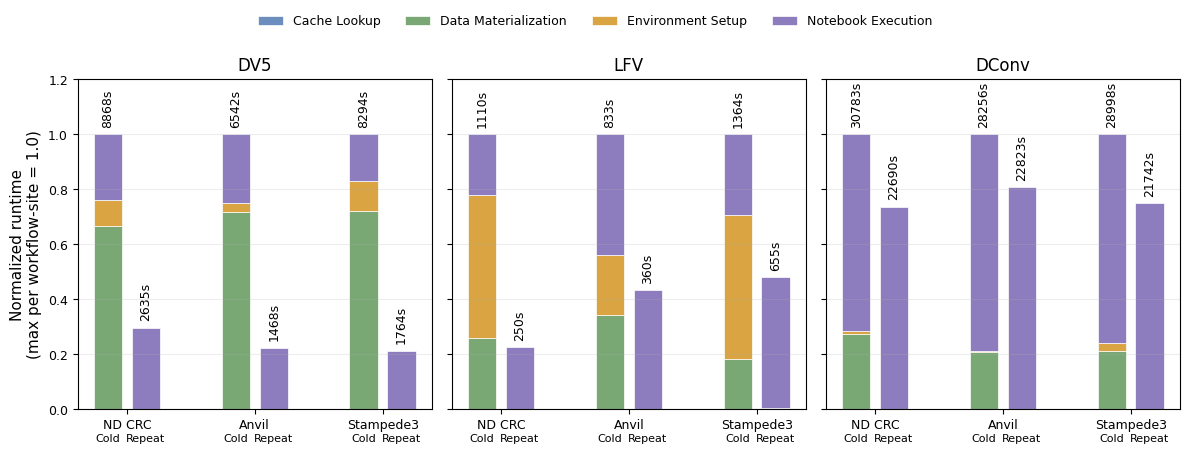

Saved: /groups/dthain/users/mislam5/benchmark-data/test-cross-site/figures/all_workflows_side_by_side_normalized.png
Saved: /groups/dthain/users/mislam5/benchmark-data/test-cross-site/figures/all_workflows_side_by_side_normalized.pdf


In [19]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(12, 4.3),
    sharey=True,
)

bar_width = 0.30
site_gap = 1.35
run_gap = 0.40

for ax, workflow in zip(axes, WORKFLOW_ORDER):
    wf_phases = normalized_phases[
        normalized_phases["workflow"] == workflow
    ].copy()

    wf_totals = normalized_totals[
        normalized_totals["workflow"] == workflow
    ].copy()

    bar_metadata = []

    for site_index, site in enumerate(SITE_ORDER):
        site_center = site_index * site_gap

        cold_x = site_center - run_gap / 2
        repeat_x = site_center + run_gap / 2

        bar_metadata.extend([
            (site, "Cold", cold_x),
            (site, "Repeat", repeat_x),
        ])

    bottoms = {
        x: 0.0
        for _, _, x in bar_metadata
    }

    for phase in PHASE_ORDER:
        x_values = []
        heights = []

        for site, run_type, x in bar_metadata:
            row = wf_phases[
                (wf_phases["site"] == site)
                & (wf_phases["run_type"] == run_type)
                & (wf_phases["phase"] == phase)
            ]

            if row.empty:
                raise ValueError(
                    f"Missing phase: {workflow}, {site}, "
                    f"{run_type}, {phase}"
                )

            value = float(row["normalized_seconds"].iloc[0])

            x_values.append(x)
            heights.append(value)

        bottom_values = [
            bottoms[x]
            for x in x_values
        ]

        ax.bar(
            x_values,
            heights,
            width=bar_width,
            bottom=bottom_values,
            color=PHASE_COLORS[phase],
            edgecolor="white",
            linewidth=0.5,
            label=phase,
        )

        for x, height in zip(x_values, heights):
            bottoms[x] += height

    # Absolute total-runtime labels.
    for site, run_type, x in bar_metadata:
        row = wf_totals[
            (wf_totals["site"] == site)
            & (wf_totals["run_type"] == run_type)
        ]

        if row.empty:
            raise ValueError(
                f"Missing total: {workflow}, {site}, {run_type}"
            )

        total_seconds = float(row["mean_seconds"].iloc[0])
        normalized_total = float(row["normalized_total"].iloc[0])

        ax.text(
            x,
            normalized_total + 0.025,
            f"{total_seconds:.0f}s",
            ha="center",
            va="bottom",
            fontsize=9,
            rotation=90,
        )

    site_centers = [
        index * site_gap
        for index in range(len(SITE_ORDER))
    ]

    ax.set_xticks(site_centers)
    ax.set_xticklabels(SITE_ORDER, fontsize=9)

    for _, run_type, x in bar_metadata:
        ax.text(
            x,
            -0.075,
            run_type,
            ha="center",
            va="top",
            fontsize=8,
            transform=ax.get_xaxis_transform(),
        )

    ax.set_title(workflow, fontsize=12)
    ax.set_ylim(0, 1.20)
    ax.grid(axis="y", alpha=0.22)
    ax.tick_params(axis="y", labelsize=9)

axes[0].set_ylabel(
    "Normalized runtime\n(max per workflow-site = 1.0)",
    fontsize=11,
)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.06),
    frameon=False,
    fontsize=9,
)

fig.tight_layout(rect=[0, 0, 1, 0.97])

fig.savefig(
    COMBINED_PNG,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    COMBINED_PDF,
    bbox_inches="tight",
)

plt.show()

print("Saved:", COMBINED_PNG.resolve())
print("Saved:", COMBINED_PDF.resolve())